# 학습데이터 생성
- 네개의 구간분포를 시퀀스로묶고 구간분포 내 구간마다 learnable embedding을 이용해 각각의 위치를 구분할수있도록 모델 스스로 구간마다 어떻게 구분할지 능동적인 학습가능성을 열어둘것이다.

In [17]:
import random
import numpy as np

# -------------------------
# 설정
# -------------------------
p = 1/125
q = 1 - p

intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, float('inf'))]

NUM_GAMES = 100000

# -------------------------
# 유틸 함수
# -------------------------

def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

def classify_interval(x):
    for i, (lo, hi) in enumerate(intervals):
        if lo <= x <= hi:
            return i
    return None

def interval_distribution(data, n):
    recent = data[-n:]
    counts = [0] * len(intervals)

    for val in recent:
        idx = classify_interval(val)
        if idx is not None:
            counts[idx] += 1

    return counts

# -------------------------
# 데이터 생성 (시퀀스 입력으로 변경)
# -------------------------

X_data = []
y_data = []

jackpot_history = []

for _ in range(NUM_GAMES):

    jackpot_num = make_jackpot_num()
    jackpot_history.append(jackpot_num)

    dist5  = interval_distribution(jackpot_history, 5)
    dist10 = interval_distribution(jackpot_history, 10)
    dist15 = interval_distribution(jackpot_history, 15)
    dist20 = interval_distribution(jackpot_history, 20)

    # 🔥 [수정 1] 20차원 → (4,5) 시퀀스 구조
    tokens = [
        dist5,
        dist10,
        dist15,
        dist20
    ]

    # 🔥 [수정 2] features 대신 tokens 사용
    X_data.append(tokens)

    label = classify_interval(jackpot_num)
    y_data.append(label)

# 🔥 [수정 3] shape 변경됨
X_data = np.array(X_data, dtype=np.float32)  # (NUM_GAMES, 4, 5)
y_data = np.array(y_data, dtype=np.int64)

print("데이터 생성 완료 (시퀀스 구조)")
print("X shape:", X_data.shape)  # (NUM_GAMES, 4, 5)
print("y shape:", y_data.shape)

데이터 생성 완료 (시퀀스 구조)
X shape: (100000, 4, 5)
y shape: (100000,)


In [18]:
# 한 칸 shift(기존 x[0] = y[0] 대응에서 x[0] = y[1]로 대응시키도록 바꾸기)
X_data = X_data[:-1]     # 마지막 X는 버림
y_data = y_data[1:]      # 첫 y는 버림

print("Shifted X shape:", X_data.shape)
print("Shifted y shape:", y_data.shape)

Shifted X shape: (99999, 4, 5)
Shifted y shape: (99999,)


In [19]:
for i in range(30):
    print(f"X[{i}] = {X_data[i]},  y[{i}] = {y_data[i]}")

X[0] = [[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]],  y[0] = 0
X[1] = [[2. 0. 0. 0. 0.]
 [2. 0. 0. 0. 0.]
 [2. 0. 0. 0. 0.]
 [2. 0. 0. 0. 0.]],  y[1] = 4
X[2] = [[2. 0. 0. 0. 1.]
 [2. 0. 0. 0. 1.]
 [2. 0. 0. 0. 1.]
 [2. 0. 0. 0. 1.]],  y[2] = 4
X[3] = [[2. 0. 0. 0. 2.]
 [2. 0. 0. 0. 2.]
 [2. 0. 0. 0. 2.]
 [2. 0. 0. 0. 2.]],  y[3] = 2
X[4] = [[2. 0. 1. 0. 2.]
 [2. 0. 1. 0. 2.]
 [2. 0. 1. 0. 2.]
 [2. 0. 1. 0. 2.]],  y[4] = 0
X[5] = [[2. 0. 1. 0. 2.]
 [3. 0. 1. 0. 2.]
 [3. 0. 1. 0. 2.]
 [3. 0. 1. 0. 2.]],  y[5] = 2
X[6] = [[1. 0. 2. 0. 2.]
 [3. 0. 2. 0. 2.]
 [3. 0. 2. 0. 2.]
 [3. 0. 2. 0. 2.]],  y[6] = 3
X[7] = [[1. 0. 2. 1. 1.]
 [3. 0. 2. 1. 2.]
 [3. 0. 2. 1. 2.]
 [3. 0. 2. 1. 2.]],  y[7] = 3
X[8] = [[1. 0. 2. 2. 0.]
 [3. 0. 2. 2. 2.]
 [3. 0. 2. 2. 2.]
 [3. 0. 2. 2. 2.]],  y[8] = 1
X[9] = [[1. 1. 1. 2. 0.]
 [3. 1. 2. 2. 2.]
 [3. 1. 2. 2. 2.]
 [3. 1. 2. 2. 2.]],  y[9] = 4
X[10] = [[0. 1. 1. 2. 1.]
 [2. 1. 2. 2. 3.]
 [3. 1. 2. 2. 3.]
 [3. 1. 2. 2. 3.]],  y[10] =

# 첫번째 모델구조

## 학습데이터에 임베딩 더하기 & 전체적 모델구조

In [12]:
# learnable embedding을 추가하는 부분 => 각 열마다 e_1, e_2... 이런식으로 자리마다 곱해지는데 각각 학습가능한 파라미터이다.

# -------------------------
# 🔥 핵심: Encoding Module
# -------------------------
import torch
import torch.nn as nn

class IntervalModelInput(nn.Module):
    def __init__(self, d_model):
        super().__init__()

        # ✔ feature embedding (열 기준)
        # feature 5개 → 각각 d_model 벡터
        self.feature_embedding = nn.Embedding(5, d_model) # nn.Embedding모듈은 각 정수ID를 행에 매칭시켜 lookup구조를 만들어주며 이때 5xd_model행렬을 만든다.

        # ✔ position embedding (행 기준)
        # sequence 길이 4 → 각 위치마다 벡터
        self.position_embedding = nn.Embedding(4, d_model)

    def forward(self, x):

        batch, seq, feat = x.shape  # seq=4, feat=5 (x.shape = (batch, seq, feat)로 만드는 의미)

        # -------------------------
        # 1️⃣ feature embedding 적용
        # -------------------------

        # feature index 생성 [0,1,2,3,4] # torch.arange() 0부터 feat-1까지 연속된 텐서를 만드는 함수
        feat_idx = torch.arange(feat).to(x.device) # 다른 device끼리 연산하지않도록 feat_idx를 x와 같은 장치에 올리도록하는 코드

        # (5, d_model)
        feat_emb = self.feature_embedding(feat_idx)

        # (batch, 4, 5, 1) # 여기서 unsqueeze는 0,1,-1만가능 2는 불가능
        x = x.unsqueeze(-1) #unsqueeze 텐서에 차원한개 추가(차원 한개 더생기는것으로 1차원 벡터가 행열로)하는 함수 반대로 squeeze는 차원한개 줄임 -1의 의미는 맨뒤에 추가하는의미

        # (batch, 4, 5, d_model)
        # 각 feature 값 × 해당 embedding
        x = x * feat_emb

        # -------------------------
        # 2️⃣ feature 합치기 (토큰 생성)
        # -------------------------

        # (batch, 4, d_model)
        # 각 행(토큰)에서 5개 feature를 합쳐 하나의 벡터로 만듦
        x = x.sum(dim=2)

        # -------------------------
        # 3️⃣ position embedding 추가
        # -------------------------

        # position index [0,1,2,3]
        pos_idx = torch.arange(seq).to(x.device)

        # (4, d_model)
        pos_emb = self.position_embedding(pos_idx)

        # broadcasting으로 (batch, 4, d_model)
        x = x + pos_emb

        return x  # transformer 입력 형태

'''
nn.Embedding = “정수 index를 벡터로 바꿔주는 학습 가능한 lookup table” : GPT 같은 LLM에서 단어를 벡터로 바꿀 때 쓰는 바로 그 방식이 (정수ID로 look up해서 학습가능한 단어임베딩행렬형성)
기본 형태 = nn.Embedding(num_embeddings, embedding_dim)
=> num_embeddings : 총 개수 (몇 개의 index가 있는지), embedding_dim : 각 index가 가지는 벡터 차원
'''

'\nnn.Embedding = “정수 index를 벡터로 바꿔주는 학습 가능한 lookup table” : GPT 같은 LLM에서 단어를 벡터로 바꿀 때 쓰는 바로 그 방식이 (정수ID로 look up해서 학습가능한 단어임베딩행렬형성)\n기본 형태 = nn.Embedding(num_embeddings, embedding_dim)\n=> num_embeddings : 총 개수 (몇 개의 index가 있는지), embedding_dim : 각 index가 가지는 벡터 차원\n'

In [13]:
# -------------------------
# 🔥 전체 모델 (간단 버전)
# -------------------------

class SimpleTransformerModel(nn.Module):
    def __init__(self, d_model=64, num_classes=5):
        super().__init__()

        # 입력 인코딩
        self.input_layer = IntervalModelInput(d_model)

        # transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # 최종 분류기
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: (batch, 4, 5)

        # 입력 인코딩
        x = self.input_layer(x)  # (batch, 4, d_model)

        # transformer
        x = self.transformer(x)  # (batch, 4, d_model)

        # 마지막 토큰 사용 (dist20 기준)
        x = x[:, -1, :]  # (batch, d_model)

        # classification
        out = self.classifier(x)

        return out

## 학습준비 확인

In [14]:
# -------------------------
# 🔥 학습 준비
# -------------------------

# MPS 사용 (Mac GPU)
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

model = SimpleTransformerModel(d_model=64).to(device)

# 텐서도 반드시 device로 이동
X_tensor = torch.tensor(X_data).to(device)
y_tensor = torch.tensor(y_data).to(device)

print("사용 디바이스:", device)
print("모델 및 텐서 준비 완료")

사용 디바이스: mps
모델 및 텐서 준비 완료


In [16]:
# -------------------------
# 🔥 데이터 확인 (20개 샘플 출력)
# -------------------------

num_samples = 20

for i in range(num_samples):
    print(f"\n===== Sample {i} =====")
    
    # X: (4,5)
    print("X (input):")
    print(X_tensor[i].cpu().numpy())  # device에 있어도 보기 쉽게 CPU로
    
    # y: label
    print("y (label):", y_tensor[i].item())


===== Sample 0 =====
X (input):
[[0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]]
y (label): 3

===== Sample 1 =====
X (input):
[[0. 0. 0. 2. 0.]
 [0. 0. 0. 2. 0.]
 [0. 0. 0. 2. 0.]
 [0. 0. 0. 2. 0.]]
y (label): 4

===== Sample 2 =====
X (input):
[[0. 0. 0. 2. 1.]
 [0. 0. 0. 2. 1.]
 [0. 0. 0. 2. 1.]
 [0. 0. 0. 2. 1.]]
y (label): 2

===== Sample 3 =====
X (input):
[[0. 0. 1. 2. 1.]
 [0. 0. 1. 2. 1.]
 [0. 0. 1. 2. 1.]
 [0. 0. 1. 2. 1.]]
y (label): 4

===== Sample 4 =====
X (input):
[[0. 0. 1. 2. 2.]
 [0. 0. 1. 2. 2.]
 [0. 0. 1. 2. 2.]
 [0. 0. 1. 2. 2.]]
y (label): 2

===== Sample 5 =====
X (input):
[[0. 0. 2. 1. 2.]
 [0. 0. 2. 2. 2.]
 [0. 0. 2. 2. 2.]
 [0. 0. 2. 2. 2.]]
y (label): 4

===== Sample 6 =====
X (input):
[[0. 0. 2. 0. 3.]
 [0. 0. 2. 2. 3.]
 [0. 0. 2. 2. 3.]
 [0. 0. 2. 2. 3.]]
y (label): 4

===== Sample 7 =====
X (input):
[[0. 0. 2. 0. 3.]
 [0. 0. 2. 2. 4.]
 [0. 0. 2. 2. 4.]
 [0. 0. 2. 2. 4.]]
y (label): 2

===== Sample 8 =====
X (input):
[[0. 0. 2. 0. 3

## 블록 설명

- 멀티헤드 어텐션은 서로 다른 관점에서 관계를 동시에 학습하도록 해준다.

- 각 head는 다음과 같은 역할을 학습할 수 있다:
  - head1 → short-term 패턴
  - head2 → long-term 패턴
  - head3 → 특정 interval 집중
  - head4 → noise 제거

- 즉, 모델이 다양한 해석 경로를 스스로 학습할 수 있도록 구조를 제공한다.

### 전체 흐름

입력 X  
→ Q, K 생성  
→ multi-head 분할  
→ QKᵀ (토큰 간 관계 계산)  
→ softmax (중요도 비율 계산)  
→ attn @ X (정보 혼합)  
→ concat (head 결합)  
→ W_o (출력 정리)  
→ residual 연결  
→ FFN (비선형 변환)  
→ residual 연결  
→ 최종 출력

In [23]:
import torch.nn.functional as F

class MultiHeadCustomBlock(nn.Module):
    def __init__(self, d_model=32, n_heads=4):
        super().__init__()

        self.d_model = d_model              # 전체 차원
        self.n_heads = n_heads              # head 개수
        self.d_head = d_model // n_heads    # head당 차원

        self.W_q = nn.Linear(d_model, d_model)  # Query 생성
        self.W_k = nn.Linear(d_model, d_model)  # Key 생성

        self.W_o = nn.Linear(d_model, d_model)  # head 결과 합치기

        self.ffn = nn.Sequential(               # 토큰별 비선형 변환
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model)
        )

        self.norm1 = nn.LayerNorm(d_model)      # attention 이후 정규화
        self.norm2 = nn.LayerNorm(d_model)      # FFN 이후 정규화

    def forward(self, x):
        B, T, D = x.shape                      # batch, 토큰 수, 차원

        Q = self.W_q(x)                        # Query
        K = self.W_k(x)                        # Key

        Q = Q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)  # head 분할
        K = K.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        X = x.view(B, T, self.n_heads, self.d_head).transpose(1, 2)  # ❗ V 대신 X

        scores = torch.matmul(Q, K.transpose(-2, -1))                # QKᵀ (관계 계산)
        scores = scores / (self.d_head ** 0.5)                       # scaling

        attn = F.softmax(scores, dim=-1)                             # 중요도

        out = torch.matmul(attn, X)                                  # 정보 mixing

        out = out.transpose(1, 2).contiguous().view(B, T, D)         # head concat

        out = self.W_o(out)                                          # 결과 정리

        x = self.norm1(x + out)                                      # residual + norm

        ffn_out = self.ffn(x)                                        # FFN

        x = self.norm2(x + ffn_out)                                  # residual + norm

        return x                                                     # 최종 출력

## 이어서 end-to-end 학습 모델

In [25]:
# -------------------------
# 🔥 전체 모델
# -------------------------

class FullModel(nn.Module):
    def __init__(self, d_model=32, n_heads=4, n_layers=4, num_classes=5):
        super().__init__()

        self.input_layer = IntervalModelInput(d_model)  
        # (B,4,5) → (B,4,d_model) 변환 (feature + position embedding)

        self.blocks = nn.ModuleList([
            MultiHeadCustomBlock(d_model, n_heads)
            for _ in range(n_layers)
        ])  
        # transformer block 여러 개 쌓기 (토큰 간 관계 학습)

        self.classifier = nn.Linear(d_model, num_classes)  
        # 최종 분류층 (d_model → 5 클래스)


    def forward(self, x):
        # x: (B, 4, 5)

        x = self.input_layer(x)  
        # 입력 인코딩 → 토큰 4개 생성 (각각 d_model 차원)

        for block in self.blocks:
            x = block(x)  
            # attention + FFN 반복 → 표현 고도화

        x = x[:, -1, :]  
        # 마지막 토큰(dist20) 선택 → 가장 많은 정보 포함

        out = self.classifier(x)  
        # (B,d_model) → (B,5) 클래스 점수 출력

        return out  
        # 최종 logits 반환 (softmax는 loss에서 처리)

In [29]:
# 학습 설정 (최적화된 값)

model = FullModel(d_model=32, n_heads=4, n_layers=6).to(device)  
# 모델 생성 + device(GPU/MPS/CPU)로 이동

criterion = nn.CrossEntropyLoss()  
# 분류용 손실 함수 (softmax 포함, 정답은 정수 그대로 사용)

optimizer = torch.optim.AdamW(
    model.parameters(),   # 모델의 모든 학습 파라미터
    lr=3e-4,              # 학습률
    weight_decay=1e-4     # 과적합 방지
)

In [30]:
# DataLoader
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(X_tensor, y_tensor)  
# X와 y를 하나의 dataset으로 묶음

train_size = int(0.8 * len(dataset))  
test_size = len(dataset) - train_size  
# 80% train / 20% test 분할

train_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, test_size])  
# dataset을 랜덤하게 train/test로 나눔

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)  
# 학습용 loader (batch 단위, shuffle로 섞어서 학습)

test_loader = DataLoader(test_ds, batch_size=512)  
# 테스트용 loader (순서 유지)

In [31]:
import torch
import torch.nn.functional as F

# -------------------------
# 🔥 학습 루프 + Early Stopping
# -------------------------

best_loss = float('inf')   # 가장 낮은 validation loss 저장
patience = 20              # 개선 없으면 20번 후 종료
counter = 0                # 개선 안된 횟수

EPOCHS = 100               # 최대 학습 epoch 수

for epoch in range(EPOCHS):
    # -------------------------
    # 🔥 Train
    # -------------------------
    model.train()
    total_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()

        out = model(xb)                 # logits (B,5)
        loss = criterion(out, yb)       # CrossEntropyLoss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # -------------------------
    # 🔥 Validation
    # -------------------------
    model.eval()
    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(test_loader):
            xb, yb = xb.to(device), yb.to(device)

            out = model(xb)                 # logits
            loss = criterion(out, yb)
            val_loss += loss.item()

            probs = F.softmax(out, dim=1)   # 🔥 확률 (추가된 부분)

            pred = out.argmax(dim=1)

            correct += (pred == yb).sum().item()
            total += yb.size(0)

            # 🔥 첫 배치만 출력 (디버깅용)
            if batch_idx == 0 and epoch % 5 == 0:
                print("\n--- 확률 샘플 ---")
                for i in range(min(3, probs.size(0))):
                    print(f"[샘플 {i}] 정답: {yb[i].item()} | 예측: {pred[i].item()}")
                    for j in range(probs.size(1)):
                        print(f"  클래스 {j}: {probs[i,j].item()*100:.2f}%") # 각 클래스를 예측한 확률을 보고 내부적으로 어느정도로 예측을 하고있는지 확인

    val_loss /= len(test_loader)
    acc = correct / total

    print(f"\nEpoch {epoch} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f} | Acc: {acc:.4f}")

    # -------------------------
    # 🔥 Early stopping
    # -------------------------
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break


--- 확률 샘플 ---
[샘플 0] 정답: 0 | 예측: 0
  클래스 0: 22.54%
  클래스 1: 18.97%
  클래스 2: 19.05%
  클래스 3: 20.76%
  클래스 4: 18.68%
[샘플 1] 정답: 2 | 예측: 2
  클래스 0: 20.32%
  클래스 1: 19.57%
  클래스 2: 20.50%
  클래스 3: 19.95%
  클래스 4: 19.66%
[샘플 2] 정답: 4 | 예측: 0
  클래스 0: 21.56%
  클래스 1: 19.43%
  클래스 2: 19.84%
  클래스 3: 20.46%
  클래스 4: 18.71%

Epoch 0 | Train Loss: 1.6154 | Val Loss: 1.6115 | Acc: 0.1983

Epoch 1 | Train Loss: 1.6103 | Val Loss: 1.6126 | Acc: 0.1943

Epoch 2 | Train Loss: 1.6108 | Val Loss: 1.6105 | Acc: 0.1946

Epoch 3 | Train Loss: 1.6101 | Val Loss: 1.6105 | Acc: 0.1984

Epoch 4 | Train Loss: 1.6101 | Val Loss: 1.6105 | Acc: 0.1971

--- 확률 샘플 ---
[샘플 0] 정답: 0 | 예측: 3
  클래스 0: 20.25%
  클래스 1: 19.42%
  클래스 2: 19.04%
  클래스 3: 20.88%
  클래스 4: 20.40%
[샘플 1] 정답: 2 | 예측: 4
  클래스 0: 18.97%
  클래스 1: 20.23%
  클래스 2: 19.69%
  클래스 3: 20.38%
  클래스 4: 20.73%
[샘플 2] 정답: 4 | 예측: 3
  클래스 0: 19.92%
  클래스 1: 19.96%
  클래스 2: 19.49%
  클래스 3: 20.82%
  클래스 4: 19.82%

Epoch 5 | Train Loss: 1.6102 | Val Loss: 1.6099 

# 모델 하이퍼파라미터 조절해보기

In [32]:
# 마지막 출력에서 입력상태와 정답도 출력해 같이 보면 더욱 어떤 상황에서 어떻게 예측했는지 알수있겠다.

'''
배치크기 조절해(손실함수 유효하게 만드는것도 고려 즉 노이즈 큰것 묻히게할방법)
출력층 결과 보며 성능 유추하며 블록개수나 층의 깊이 노드수 조절해보기 활성함수등 수정해보기 원인을 찾아야하는데 이것은 출력결과나 변화를 보고 판단가능
'''

'\n배치크기 조절해(손실함수 유효하게 만드는것도 고려 즉 노이즈 큰것 묻히게할방법)\n'

# 두번째 모델구조

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

class IntervalModelInput(nn.Module):
    def __init__(self, d_model):
        super().__init__() # 이부분은 super()를통해 부모 클래스의 함수를 호출하는것으로 부모 클래스의 init함수를 호출하여 부모클래스에 있는 변수와 함수를 그대로 사용가능
        self.feature_embedding = nn.Embedding(5, d_model) # 위 추가 설며 init은 함수로 일종의 시작하자마자 실행해야하는것이고 상태를 초기화하는 느낌이다.
        self.position_embedding = nn.Embedding(4, d_model)

    def forward(self, x):
        B, T, F_ = x.shape # B, T, F에 x.shape의 값을 각각 배치크기, 시퀀스 길이, feature 수로 할당한다.
        feat_idx = torch.arange(F_, device=x.device)
        feat_emb = self.feature_embedding(feat_idx)
        x = x.unsqueeze(-1) * feat_emb
        x = x.sum(dim=2)
        pos_idx = torch.arange(T, device=x.device)
        x = x + self.position_embedding(pos_idx)
        return x

class MultiHeadCustomBlock(nn.Module):
    def __init__(self, d_model=32, n_heads=4): # 이렇게 처음에 init함수로 주머니 만든다. 주머니 안에 클래스 재료들을 넣어둔다.
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model)
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        B, T, D = x.shape

        Q = self.W_q(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        X = x.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5)
        attn = F.softmax(scores, dim=-1)

        out = torch.matmul(attn, X)
        out = out.transpose(1, 2).contiguous().view(B, T, D) # head concat(contiguous는 메모리 상에서 텐서를 연속적으로 만들어주는 함수, view는 텐서의 모양을 바꿔주는 함수)
        out = self.W_o(out) # 위 추가설명 transpose와 같은 연산 후에는 메모리 주소가 흩어진 상태가 되어서 contiguous로 연속된 메모리 형태로 만들어주는 과정이 필요하다.


        x = self.norm1(x + out)
        x = self.norm2(x + self.ffn(x))
        return x

class FullModel(nn.Module):
    def __init__(self, d_model=32, n_heads=4, n_layers=6, num_classes=5):
        super().__init__()
        self.input_layer = IntervalModelInput(d_model)
        self.blocks = nn.ModuleList([ # ModuleList는 nn.Module을 담는 리스트로, 리스트에 담긴 모듈들이 모델의 일부로 인식되어 학습이 가능하게 해준다.
            MultiHeadCustomBlock(d_model, n_heads) for _ in range(n_layers) # 클래스 안에 함수에서 다른 클래스를 호출하여 객체를 만드는것도 가능하다. 이렇게 하면 블록을 여러개 쌓을수있다.
        ])
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.input_layer(x) # input_layer는 이 클래스의 init에 정의되어있으며 다른 클래스(IntervalModelInput)를 호출하여 FullModel에서 다른 신경망 블록들을 이용해 전체 신경망 구조를 만든다.
        for block in self.blocks:
            x = block(x)
        x = x[:, -1, :] # 텐서 슬라이싱으로 :는 전체선택, -1은 마지막 인덱스 선택이며 x의 shape이 (batch, seq, d_model)이니 각각에 대응하여 배치 전체, 마지막 토큰, 모든 차원을 선택하는 것이다.
        return self.classifier(x) # 최종적으로 클래스 점수를 반환하는데 self.classifier는 init에서 정의된 nn.Linear를 실행해 선형변환을 한번 거치고 반환하라는것이다.

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") # 현재 연결된(실행중인) Python 환경에 물어본다. MPS가 사용 가능한 경우 MPS를 사용하고, 그렇지 않으면 CPU를 사용한다는 의미이다. MPS는 Mac에서 GPU 가속을 활용하기 위한 PyTorch의 백엔드이다.
# 모델 파라미터를 해당 디바이스 메모리(GPU/MPS/CPU)로 복사하는것이다. GPU를 여러개 사용할 때는 모델을 특정 GPU로 이동시키는 것도 가능하다. 예를 들어 torch.device("cuda:0")는 첫 번째 GPU를 의미한다.
# GPU여러개를 이용해 배치를 병렬적으로 부여해 학습속도를 올리는 방법이 있는데 결국 해야하는 중요한 방법으로 DDP(DistributedDataParallel)가 있다. DDP는 모델의 복사본을 각 GPU에 만들어서 각 GPU가 배치의 일부를 처리하도록 하는 방식이다. DDP는 모델과 데이터를 각 GPU로 이동시키는 작업을 자동으로 처리해준다.
model = FullModel().to(device) # .to(device)는 모델의 모든 파라미터와 버퍼를 지정된 장치로 이동시키는 함수이다. 이렇게 하면 FullModel클래스를 실행시켜 생성한 객체를 device에 올려서 GPU나 MPS에서 연산이 가능하도록 하는 것이다.

X_tensor = torch.tensor(X_data).to(device) # device로 텐서를 이동시키는 이유는 모델과 텐서가 같은 장치에 있어야 연산이 가능하기 때문이다. 예를 들어 모델이 GPU에 있고 텐서가 CPU에 있으면 연산이 불가능하므로 둘 다 같은 장치로 이동시켜야 한다.    
y_tensor = torch.tensor(y_data).to(device)

dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=512)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

best_loss = float('inf')
patience = 20
counter = 0

for epoch in range(10): # 이 for문이 전체 학습 루프를 담당한다.
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad(): # test data는 학습에 영향을 주면 안되므로 no_grad()로 감싸서 그래디언트 계산을 하지 않도록 한다.
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            val_loss += criterion(out, yb).item()
            pred = out.argmax(dim=1)
            correct += (pred == yb).sum().item()
            total += yb.size(0) # 텐서의 첫 번째 차원 크기 (배치 크기)를 반환하는 함수

    val_loss /= len(test_loader) # /=는 나눗셈 후 다시 저장하는 복합 대입 연산자이다. 즉 val_loss = val_loss / len(test_loader)와 같은 의미이다. 이렇게 하면 전체 validation loss를 배치 수로 나누어서 평균 validation loss를 구할 수 있다.
    acc = correct / total

    print(f"Epoch {epoch} | Train {train_loss:.4f} | Val {val_loss:.4f} | Acc {acc:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            break # 이부분은 Early stopping을 구현한것이다.

Epoch 0 | Train 1.6136 | Val 1.6114 | Acc 0.1986
Epoch 1 | Train 1.6104 | Val 1.6100 | Acc 0.1984
Epoch 2 | Train 1.6098 | Val 1.6100 | Acc 0.2024
Epoch 3 | Train 1.6102 | Val 1.6103 | Acc 0.2021
Epoch 4 | Train 1.6101 | Val 1.6100 | Acc 0.1986
Epoch 5 | Train 1.6099 | Val 1.6103 | Acc 0.2019
Epoch 6 | Train 1.6100 | Val 1.6097 | Acc 0.2023
Epoch 7 | Train 1.6099 | Val 1.6096 | Acc 0.2022
Epoch 8 | Train 1.6099 | Val 1.6106 | Acc 0.1998
Epoch 9 | Train 1.6098 | Val 1.6103 | Acc 0.1972


In [ ]:
# 결과 출력 해보기

import torch
import torch.nn as nn
import torch.nn.functional as F

# -------------------------
# Input Layer
# -------------------------
class IntervalModelInput(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.feature_embedding = nn.Embedding(5, d_model)
        self.position_embedding = nn.Embedding(4, d_model)

    def forward(self, x):
        print("\n[Input Layer]")
        print("input:", x.shape)

        B, T, F_ = x.shape

        feat_idx = torch.arange(F_, device=x.device)
        feat_emb = self.feature_embedding(feat_idx)
        print("feature embedding:", feat_emb.shape)

        x = x.unsqueeze(-1)
        print("unsqueeze:", x.shape)

        x = x * feat_emb
        print("after multiply:", x.shape)

        x = x.sum(dim=2)
        print("after sum:", x.shape)

        pos_idx = torch.arange(T, device=x.device)
        pos_emb = self.position_embedding(pos_idx)
        print("pos embedding:", pos_emb.shape)

        x = x + pos_emb
        print("after pos add:", x.shape)

        return x


# -------------------------
# Transformer Block
# -------------------------
class MultiHeadCustomBlock(nn.Module):
    def __init__(self, d_model=32, n_heads=4):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model)
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        print("\n[Transformer Block]")
        print("input:", x.shape)

        B, T, D = x.shape

        Q = self.W_q(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        X = x.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        print("Q:", Q.shape)
        print("K:", K.shape)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5)
        print("scores:", scores.shape)

        attn = F.softmax(scores, dim=-1)
        print("attn:", attn.shape)

        out = torch.matmul(attn, X)
        print("attn * X:", out.shape)

        out = out.transpose(1, 2).contiguous().view(B, T, D)
        print("concat:", out.shape)

        out = self.W_o(out)
        print("after W_o:", out.shape)

        x = self.norm1(x + out)
        print("after norm1:", x.shape)

        x = self.norm2(x + self.ffn(x))
        print("after norm2:", x.shape)

        return x


# -------------------------
# Full Model
# -------------------------
class FullModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_layer = IntervalModelInput(32)
        self.blocks = nn.ModuleList([MultiHeadCustomBlock() for _ in range(2)])
        self.classifier = nn.Linear(32, 5)

    def forward(self, x):
        print("\n===== FORWARD START =====")

        x = self.input_layer(x)
        print("\nAfter input layer:", x.shape)

        for i, block in enumerate(self.blocks):
            print(f"\n--- Block {i} ---")
            x = block(x)

        x = x[:, -1, :]
        print("\nAfter last token:", x.shape)

        x = self.classifier(x)
        print("After classifier:", x.shape)

        print("===== FORWARD END =====\n")

        return x


# -------------------------
# 실행 테스트
# -------------------------
device = torch.device("cpu")

model = FullModel().to(device)

# 더미 입력 (batch=2, seq=4, feature=5)
x = torch.randn(2, 4, 5).to(device)

out = model(x)

print("\nFinal output:", out)

# 세번째 모델구조(아주 중요한 직관 얻음 => but 이 코드 자체에서 학습데이터를 생성하여 엉터리로 만든거였네..)
- 두번째 모델을 기반으로 내 생각에 따라 구조 첨삭. 그렇게하여 성공함 두번째꺼는 GPT가 쥐뿔도 모르면서 추천해주는 대로했는데 학습불가능하다던 논리도 틀렸고(이것이 인공지능의 고정관념적 한계 유연하지 못하다.) 포지션널과 같은 임베딩을 learnable임베딩으로 하여 지표의 의미도 모르는것처럼 lookup구조를 만들라고 하거나 V를 추가하면 성능이 올라갈것이라고(성능 오히려 내려갔었음) 책에 적혀있는것을 읽어주는듯이 추천함 사람처럼 복합적으로 생각하는데 아직 한계 명확

- 결국 한 지표만으로 성능 낼수있는것 확인했고 사람이 느끼는 유효한 지표를 수학적으로도 검증해서 그것을 이용해 인공지능이 학습하도록 하면 유효한 결과가 나온다. 이렇게 유효한 지표들을 찾아서 이것들을 최종적으로 모아 더큰 구조로 멀티헤드들의 멀티헤드로 모아 신경망을 앙상블하는 신경망 앙상블학습법도 가능하며 매우 강력할것이다 주식투자 인공지능에도 이용할수있다.

- 추가로 early stopping넣고 예측한거 출력해서 보이도록해보기

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# -------------------------
# Transformer Block
# -------------------------
class MultiHeadCustomBlock(nn.Module):
    def __init__(self, d_model=5, n_heads=1):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model)
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        B, T, D = x.shape

        Q = self.W_q(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        X = x.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5)
        attn = F.softmax(scores, dim=-1)

        out = torch.matmul(attn, X)
        out = out.transpose(1, 2).contiguous().view(B, T, D)
        out = self.W_o(out)

        x = self.norm1(x + out)
        x = self.norm2(x + self.ffn(x))
        return x


# -------------------------
# Full Model
# -------------------------
class FullModel(nn.Module):
    def __init__(self, d_model=5, n_heads=1, n_layers=6, num_classes=5):
        super().__init__()

        self.blocks = nn.ModuleList([
            MultiHeadCustomBlock(d_model, n_heads) for _ in range(n_layers)
        ])

        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        for block in self.blocks:
            x = block(x)

        x = x[:, -1, :] # 마지막 토큰 선택
        return self.classifier(x)


# -------------------------
# 더미 데이터 생성
# -------------------------
device = torch.device("cpu")

# (샘플 1000개, T=4, F=5)
X_data = torch.randn(1000, 4, 5) # 랜덤으로 데이터를 생성 하는 부분이다.
y_data = torch.randint(0, 5, (1000,))

X_tensor = X_data.to(device)
y_tensor = y_data.to(device)

dataset = TensorDataset(X_tensor, y_tensor)

train_loader = DataLoader(dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(dataset, batch_size=64)


# -------------------------
# 학습 설정
# -------------------------
model = FullModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

# -------------------------
# 학습 루프
# -------------------------
for epoch in range(1000):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_idx, (xb, yb) in enumerate(test_loader):
            xb, yb = xb.to(device), yb.to(device)

            out = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item()

            probs = F.softmax(out, dim=1)   # 🔥 확률

            pred = out.argmax(dim=1)

            correct += (pred == yb).sum().item()
            total += yb.size(0)

            # 🔥 디버깅 출력 (5 epoch마다, 첫 batch만)
            if batch_idx == 0 and epoch % 5 == 0:
                print("\n--- 확률 샘플 ---")
                for i in range(min(3, probs.size(0))):
                    print(f"[샘플 {i}] 정답: {yb[i].item()} | 예측: {pred[i].item()}")
                    for j in range(probs.size(1)):
                        print(f"  클래스 {j}: {probs[i,j].item()*100:.2f}%")

    val_loss /= len(test_loader)
    acc = correct / total

    print(f"\nEpoch {epoch} | Train {train_loss:.4f} | Val {val_loss:.4f} | Acc {acc:.4f}")


--- 확률 샘플 ---
[샘플 0] 정답: 3 | 예측: 2
  클래스 0: 20.30%
  클래스 1: 8.31%
  클래스 2: 36.06%
  클래스 3: 9.06%
  클래스 4: 26.27%
[샘플 1] 정답: 3 | 예측: 0
  클래스 0: 31.07%
  클래스 1: 14.95%
  클래스 2: 27.15%
  클래스 3: 20.36%
  클래스 4: 6.47%
[샘플 2] 정답: 2 | 예측: 2
  클래스 0: 23.22%
  클래스 1: 12.97%
  클래스 2: 40.37%
  클래스 3: 18.21%
  클래스 4: 5.23%

Epoch 0 | Train 1.8259 | Val 1.7986 | Acc 0.2070

Epoch 1 | Train 1.7777 | Val 1.7582 | Acc 0.2000

Epoch 2 | Train 1.7431 | Val 1.7291 | Acc 0.2050

Epoch 3 | Train 1.7180 | Val 1.7074 | Acc 0.2150

Epoch 4 | Train 1.6988 | Val 1.6904 | Acc 0.2250

--- 확률 샘플 ---
[샘플 0] 정답: 3 | 예측: 2
  클래스 0: 23.25%
  클래스 1: 17.63%
  클래스 2: 23.60%
  클래스 3: 13.80%
  클래스 4: 21.72%
[샘플 1] 정답: 3 | 예측: 0
  클래스 0: 26.27%
  클래스 1: 24.07%
  클래스 2: 18.72%
  클래스 3: 22.07%
  클래스 4: 8.88%
[샘플 2] 정답: 2 | 예측: 1
  클래스 0: 21.75%
  클래스 1: 25.40%
  클래스 2: 23.57%
  클래스 3: 22.16%
  클래스 4: 7.12%

Epoch 5 | Train 1.6835 | Val 1.6764 | Acc 0.2200

Epoch 6 | Train 1.6708 | Val 1.6647 | Acc 0.2270

Epoch 7 | Train 1.6

# 네번째 코드 마지막으로 입력과 정답까지 다 보고 어떻게 예측했는지 까지 보기

## 프로젝트 구조 예시 (GPT 스타일)

보통 프로젝트는 다음과 같이 파일 단위로 나눠서 관리한다:

In [11]:
'''
project/
│
├── model/ # 모델 구조 정의
│ ├── transformer.py # 트랜스포머 블록, attention 등 핵심 구조
│ └── model.py # 전체 모델 (FullModel 등)
│
├── data/ # 데이터 처리
│ ├── dataset.py # Dataset 클래스 정의
│ ├── preprocess.py # 데이터 전처리 (정규화, 토큰화 등)
│ └── loader.py # DataLoader 생성
│
├── train/ # 학습 로직
│ ├── train.py # 학습 루프
│ └── optimizer.py # optimizer, scheduler 설정
│
├── eval/ # 평가
│ ├── evaluate.py # validation/test 평가 코드
│ └── metrics.py # accuracy, loss 등 지표 계산
│
├── config/ # 설정 # 모델 코드와 분리된 이유는 같은구조인데 하이퍼파라미터나 설정값을 바꿔가며 실험하기 편하게 하기 위해서이다. 모델코드에 하이퍼파라미터가 섞여있으면 수정하기도 어렵고 실험할 때마다 모델코드를 건드려야하는 불편함이 있다.
│ ├── config.py # 하이퍼파라미터 정의
│ └── args.py # argparse 또는 설정 관리
│
├── utils/ # 공통 함수
│ ├── logger.py # 로그 출력
│ ├── seed.py # 랜덤 시드 고정
│ └── helper.py # 기타 유틸 함수
│
└── main.py # 실행 entry point (전체 실행 시작)
'''

'\nproject/\n│\n├── model/ # 모델 구조 정의\n│ ├── transformer.py # 트랜스포머 블록, attention 등 핵심 구조\n│ └── model.py # 전체 모델 (FullModel 등)\n│\n├── data/ # 데이터 처리\n│ ├── dataset.py # Dataset 클래스 정의\n│ ├── preprocess.py # 데이터 전처리 (정규화, 토큰화 등)\n│ └── loader.py # DataLoader 생성\n│\n├── train/ # 학습 로직\n│ ├── train.py # 학습 루프\n│ └── optimizer.py # optimizer, scheduler 설정\n│\n├── eval/ # 평가\n│ ├── evaluate.py # validation/test 평가 코드\n│ └── metrics.py # accuracy, loss 등 지표 계산\n│\n├── config/ # 설정 # 모델 코드와 분리된 이유는 같은구조인데 하이퍼파라미터나 설정값을 바꿔가며 실험하기 편하게 하기 위해서이다. 모델코드에 하이퍼파라미터가 섞여있으면 수정하기도 어렵고 실험할 때마다 모델코드를 건드려야하는 불편함이 있다.\n│ ├── config.py # 하이퍼파라미터 정의\n│ └── args.py # argparse 또는 설정 관리\n│\n├── utils/ # 공통 함수\n│ ├── logger.py # 로그 출력\n│ ├── seed.py # 랜덤 시드 고정\n│ └── helper.py # 기타 유틸 함수\n│\n└── main.py # 실행 entry point (전체 실행 시작)\n'

In [22]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# -------------------------
# 설정
# -------------------------
intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, float('inf'))]
NUM_GAMES = 10000

# -------------------------
# 데이터 생성 함수
# -------------------------
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

def classify_interval(x): # 이 함수에서 정의된 x는 함수안에서 사용되는 지역변수로서 함수 밖에서는 사용할수없다. 함수 호출할때 이 x 자리에 값이 대입된다. 예를 들어 classify_interval(50)이라고 호출하면 x는 50이 되고, classify_interval(150)이라고 호출하면 x는 150이 되는 것이다. 이렇게 함수가 호출될 때마다 x에 다른 값이 들어가면서 함수 내부에서 그 값이 어떤 구간에 속하는지 판단하는 것이다.
    for i, (lo, hi) in enumerate(intervals): # enumerate는 리스트의 요소와 인덱스를 동시에 반환하는 함수이다. 여기서는 intervals 리스트의 각 요소(구간)와 그 인덱스를 i와 (lo, hi)로 받아서 구간 분류를 하는 것이다.
        if lo <= x <= hi:
            return i # 예를 들어 enumerate로 intervals 리스트를 순회할 때, 첫 번째 요소 (1, 28)는 인덱스 0과 함께 반환되고, 두 번째 요소 (29, 64)는 인덱스 1과 함께 반환된다. classify_interval 함수는 입력 x가 어느 구간에 속하는지 확인하고 해당 구간의 인덱스를 반환한다.

def interval_distribution(data, n):
    recent = data[-n:]
    counts = [0] * len(intervals)

    for val in recent:
        idx = classify_interval(val)
        counts[idx] += 1

    return counts

# -------------------------
# 데이터 생성
# -------------------------
X_data = []
y_data = []
jackpot_history = []

for _ in range(NUM_GAMES):
    jackpot_num = make_jackpot_num()
    jackpot_history.append(jackpot_num)

    dist5  = interval_distribution(jackpot_history, 5)
    dist10 = interval_distribution(jackpot_history, 10)
    dist15 = interval_distribution(jackpot_history, 15)
    dist20 = interval_distribution(jackpot_history, 20)

    tokens = [dist5, dist10, dist15, dist20]

    X_data.append(tokens)
    y_data.append(classify_interval(jackpot_num))

X_data = np.array(X_data, dtype=np.float32)
y_data = np.array(y_data, dtype=np.int64)

# shift (다음 값 예측)
X_data = X_data[:-1]
y_data = y_data[1:]

print("데이터 shape:", X_data.shape, y_data.shape)
for i in range(10):
    print(f"X[{i}] = {X_data[i]}  |  y[{i}] = {y_data[i]}")

데이터 shape: (9999, 4, 5) (9999,)
X[0] = [[0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]]  |  y[0] = 4
X[1] = [[0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]
 [0. 0. 0. 1. 1.]]  |  y[1] = 1
X[2] = [[0. 1. 0. 1. 1.]
 [0. 1. 0. 1. 1.]
 [0. 1. 0. 1. 1.]
 [0. 1. 0. 1. 1.]]  |  y[2] = 0
X[3] = [[1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1.]
 [1. 1. 0. 1. 1.]]  |  y[3] = 3
X[4] = [[1. 1. 0. 2. 1.]
 [1. 1. 0. 2. 1.]
 [1. 1. 0. 2. 1.]
 [1. 1. 0. 2. 1.]]  |  y[4] = 3
X[5] = [[1. 1. 0. 2. 1.]
 [1. 1. 0. 3. 1.]
 [1. 1. 0. 3. 1.]
 [1. 1. 0. 3. 1.]]  |  y[5] = 4
X[6] = [[1. 1. 0. 2. 1.]
 [1. 1. 0. 3. 2.]
 [1. 1. 0. 3. 2.]
 [1. 1. 0. 3. 2.]]  |  y[6] = 1
X[7] = [[1. 1. 0. 2. 1.]
 [1. 2. 0. 3. 2.]
 [1. 2. 0. 3. 2.]
 [1. 2. 0. 3. 2.]]  |  y[7] = 0
X[8] = [[1. 1. 0. 2. 1.]
 [2. 2. 0. 3. 2.]
 [2. 2. 0. 3. 2.]
 [2. 2. 0. 3. 2.]]  |  y[8] = 2
X[9] = [[1. 1. 1. 1. 1.]
 [2. 2. 1. 3. 2.]
 [2. 2. 1. 3. 2.]
 [2. 2. 1. 3. 2.]]  |  y[9] = 3


In [24]:
# -------------------------
# 모델
# -------------------------
class MultiHeadCustomBlock(nn.Module):
    def __init__(self, d_model=5, n_heads=1):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Linear(d_model * 4, d_model)
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        B, T, D = x.shape

        Q = self.W_q(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        X = x.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_head ** 0.5) # (-2,-1)은 마지막 두 차원을 의미한다. K의 shape이 (B, n_heads, T, d_head)일 때 K.transpose(-2, -1)은 (B, n_heads, d_head, T)가 된다. 이렇게 하면 Q와 K의 내적이 가능해진다.
        attn = F.softmax(scores, dim=-1) # 위에 (-2,-1)은 (2,3)과 같다 K의 shape을 보면 알수있다.

        out = torch.matmul(attn, X) # matmul 함수는 두 텐서의 행렬 곱을 계산하는 함수이다. attn의 shape이 (B, n_heads, T, T)이고 X의 shape이 (B, n_heads, T, d_head)일 때, out의 shape은 (B, n_heads, T, d_head)가 된다. 이렇게 하면 attention 가중치가 적용된 X의 표현이 만들어진다.
        out = out.transpose(1, 2).contiguous().view(B, T, D) # matmul은 뒤에 두 요소가 행렬곱 가능하면 서로 매칭되는 대응되는 두 행렬을 행렬곱 하는 함수이다. attn의 shape이 (B, n_heads, T, T)이고 X의 shape이 (B, n_heads, T, d_head)일 때, out의 shape은 (B, n_heads, T, d_head)가 된다.
        out = self.W_o(out) # matmul은 @과 같은 연산자이다.

        x = self.norm1(x + out)
        x = self.norm2(x + self.ffn(x))
        return x

class FullModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.blocks = nn.ModuleList([MultiHeadCustomBlock() for _ in range(2)])
        self.classifier = nn.Linear(5, 5)

    def forward(self, x): # self는 일종의 자기 자신에게 포함시키는 변수를 만들때 사용하는 표식이다. self.과 같이 표시한다. self는 객체 자체로 여기서는 함수 def forward를 가르친다.
        for block in self.blocks: # 이렇게 함수마다 정의 되는 self는 지역변수로서 함수가 호출될 때마다 새롭게 만들어지는 변수이다.
            x = block(x)
        x = x[:, -1, :] # 마지막 토큰 선택 / [:,-1,:]인것을 보면 이 함수에 들어오는 입력 x의 shape이 (batch, seq, d_model)이라는 것을 알 수 있다. 즉 3차원 텐서인것을 알수있다.
        return self.classifier(x)

# -------------------------
# 데이터 → torch
# -------------------------
device = torch.device("cpu")

X_tensor = torch.tensor(X_data, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_data, dtype=torch.long).to(device)

indices = torch.arange(len(X_tensor))

dataset = TensorDataset(X_tensor, y_tensor, indices)

# -------------------------
# 🔥 순서 유지 train/test split (중요)
# -------------------------
train_size = int(0.8 * len(dataset))

train_ds = torch.utils.data.Subset(dataset, list(range(train_size)))
test_ds  = torch.utils.data.Subset(dataset, list(range(train_size, len(dataset))))

# -------------------------
# 🔥 shuffle 제거
# -------------------------
train_loader = DataLoader(train_ds, batch_size=64, shuffle=False) # train_loader는 DataLoader클래스로 만든 객체로 train_ds를 배치 단위로 묶어서 제공하는 역할을 한다. shuffle=False로 설정했기 때문에 데이터가 순서대로 제공된다. 이렇게 하면 시퀀스 모델이 시간적 순서를 학습할 수 있다.
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

In [25]:
# early stopping
best_val_loss = float('inf')
patience = 20
counter = 0
best_model_state = None

# -------------------------
# 학습
# -------------------------
model = FullModel().to(device) # 이렇게 model을 준비해놓은 FullModel 클래스로 객체로 만들어서 device로 이동시키는구나
criterion = nn.CrossEntropyLoss() # 이것도 CrossEntropyLoss 클래스로 객체 만드는거다.
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4) # model.parameters()는 모델의 모든 학습 가능한 파라미터를 반환하는 함수이다. 이렇게 하면 optimizer가 모델의 모든 파라미터를 관리할 수 있게 된다.

for epoch in range(200):

    # train
    model.train() # .train()는 모델을 학습 모드로 전환하는 함수로 .eval()와 짝을 이루는 함수이다.
    train_loss = 0 # train_loss는 epoch마다 초기화해서 배치마다 누적하는 방식으로 평균 loss를 구하는 것이다. 그래서 epoch이 바뀔 때마다 train_loss를 0으로 초기화하는 것이다.

    for xb, yb, _ in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb) # loss는 텐서로 그 차원은 (batch_size,)이 될 것이다. 사실상 1차원 텐서(스칼라 텐서)로 이후 loss.item()으로 스칼라 값으로 변환해서 평균 loss를 구하는 것이다.

        loss.backward() # .backward()는 손실(loss)에 대한 그래디언트를 계산하는 함수이다. 즉 미분을 통해 각 파라미터가 손실에 얼마나 기여하는지를 계산하는 것이다. 이렇게 계산된 그래디언트는 optimizer.step()에서 파라미터를 업데이트하는 데 사용된다.
        optimizer.step() # .step()는 optimizer가 관리하는 모든 파라미터를 업데이트하는 함수이다. .backward()로 계산된 그래디언트를 사용하여 각 파라미터를 조정하는 것이다.

        train_loss += loss.item() # .item()은 텐서에서 스칼라 값을 추출하는 함수이다. loss는 텐서이지만 train_loss는 숫자여야 하므로 loss.item()을 사용하여 텐서에서 값을 꺼내서 train_loss에 누적하는 것이다.

    train_loss /= len(train_loader)

    # validation
    model.eval() # .eval()는 모델을 평가 모드로 전환하는 함수이다. 이 함수는 모델의 동작 방식을 변경하여 드롭아웃과 배치 정규화와 같은 레이어가 학습 모드에서 평가 모드로 전환되도록 한다. 이렇게 하면 모델이 예측을 할 때 일관된 결과를 얻을 수 있다. 평가 모드에서는 드롭아웃이 비활성화되고 배치 정규화가 고정된 통계값을 사용하게 된다. 따라서 모델이 학습 중에 사용한 것과 동일한 방식으로 예측을 수행할 수 있게 된다.
    val_loss = 0
    correct = 0
    total = 0
# with는 자원(resource)을 안전하게 열고, 끝나면 자동으로 정리해주는 문법이다. 여기서는 torch.no_grad()를 사용하여 그래디언트 계산을 비활성화하는 컨텍스트를 만들고 있다. 이렇게 하면 validation 단계에서 모델이 학습에 영향을 주지 않도록 할 수 있다.
    with torch.no_grad(): # validation 단계에서는 모델이 학습에 영향을 주면 안되므로 no_grad()로 감싸서 그래디언트 계산을 하지 않도록 한다. KV캐시와 유사하게 모델이 예측을 할 때 필요한 계산만 수행하도록 하는 것이다.
        for batch_idx, (xb, yb, idx) in enumerate(test_loader): # enumerate는 반복 가능한 객체(리스트, 튜플 등)를 돌면서 "인덱스 + 값"을 같이 꺼내주는 함수이다. 여기서는 test_loader에서 배치 단위로 데이터를 꺼내면서 배치 인덱스(batch_idx)와 데이터(xb, yb, idx)를 함께 가져오는 것이다. 이렇게 하면 각 배치가 몇 번째 배치인지 알 수 있고, xb는 입력 데이터, yb는 정답 레이블, idx는 원본 데이터에서 해당 배치의 인덱스를 나타낸다.
            xb, yb = xb.to(device), yb.to(device)

            out = model(xb)
            val_loss += criterion(out, yb).item()

            probs = F.softmax(out, dim=1)
            pred = out.argmax(dim=1)

            correct += (pred == yb).sum().item()
            total += yb.size(0)

            # 🔥 디버깅 출력
            if batch_idx == 0 and epoch % 10 == 0:
                print("\n=== 디버깅 샘플 ===")

                for i in range(10):
                    real_idx = idx[i].item()

                    print(f"\n[샘플 index: {real_idx}]")

                    print("원본 X_data:")
                    print(X_data[real_idx])

                    print("원본 y_data:", y_data[real_idx])

                    print("예측:", pred[i].item())

                    print("확률:")
                    for j in range(5):
                        print(f"  class {j}: {probs[i,j].item()*100:.2f}%")

    val_loss /= len(test_loader)
    acc = correct / total

    print(f"\nEpoch {epoch} | Train {train_loss:.4f} | Val {val_loss:.4f} | Acc {acc:.4f}")

    # -------------------------
    # 🔥 Early Stopping
    # -------------------------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        best_model_state = model.state_dict()  # 현재까지 가장 좋은 모델 저장
        print("✅ Best model updated")
    else:
        counter += 1
        print(f"⏳ EarlyStopping counter: {counter}/{patience}")

    if counter >= patience:
        print("\n🛑 Early stopping triggered!")
        break

# -------------------------
# 🔥 best 모델 복원
# -------------------------
if best_model_state is not None: # 가장 좋았던 모델이 저장되어 있다면 그 모델의 상태를 현재 모델에 복원하는 것이다.
    model.load_state_dict(best_model_state)
    print("🎯 Best model restored")
# 출력 결과를 보면 샘플이 7999부터 나오는데 그 이유는 test_loader가 train_loader에서 80%로 나눈 뒤 나머지 20%를 test_loader로 사용하기 때문이다.
# 그리고 에포크 반복하며 50 에포크마다 샘플과 예측결과 출력하는데 계속 같은 이유는 계속 같은 test_loader의 첫 배치를 출력하기 때문이다.


=== 디버깅 샘플 ===

[샘플 index: 7999]
원본 X_data:
[[1. 0. 1. 1. 2.]
 [1. 1. 1. 4. 3.]
 [1. 2. 4. 4. 4.]
 [2. 2. 6. 5. 5.]]
원본 y_data: 2
예측: 3
확률:
  class 0: 18.88%
  class 1: 9.49%
  class 2: 23.27%
  class 3: 24.58%
  class 4: 23.78%

[샘플 index: 8000]
원본 X_data:
[[1. 0. 1. 1. 2.]
 [1. 1. 2. 3. 3.]
 [1. 1. 5. 4. 4.]
 [2. 2. 6. 5. 5.]]
원본 y_data: 0
예측: 3
확률:
  class 0: 19.15%
  class 1: 9.47%
  class 2: 23.48%
  class 3: 24.26%
  class 4: 23.64%

[샘플 index: 8001]
원본 X_data:
[[2. 0. 1. 1. 1.]
 [2. 0. 2. 3. 3.]
 [2. 1. 4. 4. 4.]
 [3. 2. 6. 5. 4.]]
원본 y_data: 4
예측: 2
확률:
  class 0: 19.27%
  class 1: 9.52%
  class 2: 24.22%
  class 3: 23.68%
  class 4: 23.31%

[샘플 index: 8002]
원본 X_data:
[[2. 0. 1. 0. 2.]
 [2. 0. 2. 2. 4.]
 [2. 1. 4. 4. 4.]
 [3. 2. 5. 5. 5.]]
원본 y_data: 1
예측: 3
확률:
  class 0: 18.16%
  class 1: 9.57%
  class 2: 22.73%
  class 3: 25.55%
  class 4: 24.00%

[샘플 index: 8003]
원본 X_data:
[[1. 1. 1. 0. 2.]
 [2. 1. 2. 1. 4.]
 [2. 2. 3. 4. 4.]
 [3. 3. 5. 4. 5.]]
원본 y_data: 3
예측: 4
확률:
  c

# PCA를 통한 데이터 분석과 언어모델 임베딩행렬은 t-sne나 umap이 유효할수도(king - queen과 같은 경우 의미거리가 나오는 꼴이기 때문에 특징간 상관관계가 없는 경우 PCA분석은 효용성 낮아보인다.)

In [7]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# -------------------------
# 설정
# -------------------------
intervals = [(1, 28), (29, 64), (65, 115), (116, 200), (201, float('inf'))]
NUM_GAMES = 10000

# -------------------------
# 데이터 생성 함수
# -------------------------
def make_jackpot_num():
    jackpot_num = 1
    while True:
        if random.randint(1, 125) == 1:
            return jackpot_num
        jackpot_num += 1

def classify_interval(x): # 이 함수에서 정의된 x는 함수안에서 사용되는 지역변수로서 함수 밖에서는 사용할수없다. 함수 호출할때 이 x 자리에 값이 대입된다. 예를 들어 classify_interval(50)이라고 호출하면 x는 50이 되고, classify_interval(150)이라고 호출하면 x는 150이 되는 것이다. 이렇게 함수가 호출될 때마다 x에 다른 값이 들어가면서 함수 내부에서 그 값이 어떤 구간에 속하는지 판단하는 것이다.
    for i, (lo, hi) in enumerate(intervals): # enumerate는 리스트의 요소와 인덱스를 동시에 반환하는 함수이다. 여기서는 intervals 리스트의 각 요소(구간)와 그 인덱스를 i와 (lo, hi)로 받아서 구간 분류를 하는 것이다.
        if lo <= x <= hi:
            return i # 예를 들어 enumerate로 intervals 리스트를 순회할 때, 첫 번째 요소 (1, 28)는 인덱스 0과 함께 반환되고, 두 번째 요소 (29, 64)는 인덱스 1과 함께 반환된다. classify_interval 함수는 입력 x가 어느 구간에 속하는지 확인하고 해당 구간의 인덱스를 반환한다.

def interval_distribution(data, n):
    recent = data[-n:]
    counts = [0] * len(intervals)

    for val in recent:
        idx = classify_interval(val)
        counts[idx] += 1

    return counts

# -------------------------
# 데이터 생성
# -------------------------
X_data = []
y_data = []
jackpot_history = []

for _ in range(NUM_GAMES):
    jackpot_num = make_jackpot_num()
    jackpot_history.append(jackpot_num)

    dist5  = interval_distribution(jackpot_history, 5)
    dist10 = interval_distribution(jackpot_history, 10)
    dist15 = interval_distribution(jackpot_history, 15)
    dist20 = interval_distribution(jackpot_history, 20)

    tokens = [dist5, dist10, dist15, dist20]

    X_data.append(tokens)
    y_data.append(classify_interval(jackpot_num))

X_data = np.array(X_data, dtype=np.float32)
y_data = np.array(y_data, dtype=np.int64)

# shift (다음 값 예측)
X_data = X_data[:-1]
y_data = y_data[1:]

print("데이터 shape:", X_data.shape, y_data.shape)
for i in range(10):
    print(f"X[{i}] = {X_data[i]}  |  y[{i}] = {y_data[i]}")

데이터 shape: (9999, 4, 5) (9999,)
X[0] = [[0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]  |  y[0] = 1
X[1] = [[0. 2. 0. 0. 0.]
 [0. 2. 0. 0. 0.]
 [0. 2. 0. 0. 0.]
 [0. 2. 0. 0. 0.]]  |  y[1] = 1
X[2] = [[0. 3. 0. 0. 0.]
 [0. 3. 0. 0. 0.]
 [0. 3. 0. 0. 0.]
 [0. 3. 0. 0. 0.]]  |  y[2] = 0
X[3] = [[1. 3. 0. 0. 0.]
 [1. 3. 0. 0. 0.]
 [1. 3. 0. 0. 0.]
 [1. 3. 0. 0. 0.]]  |  y[3] = 1
X[4] = [[1. 4. 0. 0. 0.]
 [1. 4. 0. 0. 0.]
 [1. 4. 0. 0. 0.]
 [1. 4. 0. 0. 0.]]  |  y[4] = 1
X[5] = [[1. 4. 0. 0. 0.]
 [1. 5. 0. 0. 0.]
 [1. 5. 0. 0. 0.]
 [1. 5. 0. 0. 0.]]  |  y[5] = 4
X[6] = [[1. 3. 0. 0. 1.]
 [1. 5. 0. 0. 1.]
 [1. 5. 0. 0. 1.]
 [1. 5. 0. 0. 1.]]  |  y[6] = 1
X[7] = [[1. 3. 0. 0. 1.]
 [1. 6. 0. 0. 1.]
 [1. 6. 0. 0. 1.]
 [1. 6. 0. 0. 1.]]  |  y[7] = 4
X[8] = [[0. 3. 0. 0. 2.]
 [1. 6. 0. 0. 2.]
 [1. 6. 0. 0. 2.]
 [1. 6. 0. 0. 2.]]  |  y[8] = 2
X[9] = [[0. 2. 1. 0. 2.]
 [1. 6. 1. 0. 2.]
 [1. 6. 1. 0. 2.]
 [1. 6. 1. 0. 2.]]  |  y[9] = 4


Flatten shape: (9999, 20)
PCA 결과 shape: (9999, 2)


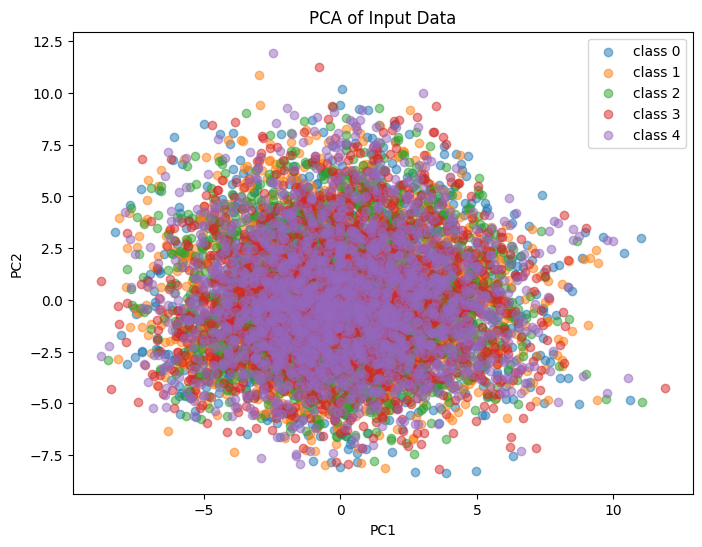

Explained variance ratio: [0.22380999 0.21337955]


In [8]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -------------------------
# 1️⃣ flatten (N, 4, 5) → (N, 20)
# -------------------------
X_flat = X_data.reshape(len(X_data), -1)

print("Flatten shape:", X_flat.shape)  # (N, 20)

# -------------------------
# 2️⃣ PCA 수행
# -------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_flat)

print("PCA 결과 shape:", X_pca.shape)

# -------------------------
# 3️⃣ 시각화 (label 색칠)
# -------------------------
plt.figure(figsize=(8,6)) # figsize = 

for cls in range(5):
    idx = (y_data == cls)
    plt.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        label=f"class {cls}",
        alpha=0.5
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Input Data")
plt.legend()
plt.show()

# -------------------------
# 4️⃣ 설명된 분산 비율 확인
# -------------------------
print("Explained variance ratio:", pca.explained_variance_ratio_)

# 그러나 현재 언어모델 임베딩행렬의 경우 PCA분석 어려울것같은데 중간에 신경망이 적절히 처리해주고 유사한것들은 유사한곳으로 가고 대상자체의 위치까지 변화시켜주기 때문에 가능한것같다
# 그래서 가까운 점들끼리 모이게하는 t sne나 u map이 오히려 임베딩행렬의 유사한 단어들끼리 모아준다고한다.

### 주피터노트북에서는 잘돌아가던 코드가 vscode에서 안돌아갔었는데 이런경우 저장후 껐다가 다시 켜서 가상환경 연결 동일하게 해주면 고쳐질수있다.(가상환경 연결하면 해당 환경안에있는 파일들을 이용해 실행하게된다. 그래서 가상환경 연결이 잘못되면 필요한 라이브러리를 못찾아서 에러가 날수있다.)

In [2]:
import sys
import numpy
import scipy

print("Python:", sys.executable)
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)

Python: /Users/pc/miniforge3/envs/research/bin/python
NumPy: 2.2.6
SciPy: 1.15.2


In [3]:
import sys, numpy

print("Python:", sys.executable)
print("NumPy version:", numpy.__version__)
print("NumPy path:", numpy.__file__)

Python: /Users/pc/miniforge3/envs/research/bin/python
NumPy version: 2.2.6
NumPy path: /Users/pc/miniforge3/envs/research/lib/python3.10/site-packages/numpy/__init__.py


In [4]:
import numpy, scipy, sklearn
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)

numpy: 2.2.6
scipy: 1.15.2
sklearn: 1.7.2
